In [71]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
# for google colab

# !pip install pypose
# !pip install kornia

In [73]:
# from google.colab import drive
# drive.mount('/content/drive')

In [74]:
# %cd /content/
# !git clone https://github.com/MarcinJanis/SonarOdometry.git
# %cd SonarOdometry

In [75]:
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F


import numpy as np
import cv2
from scipy.spatial.transform import Rotation as R

from box import Box
import yaml

import matplotlib.pyplot as plt
from tqdm import tqdm

import random
import time

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.evaluation_data_generator import DataGenerator
from src.models.patchifier import Patchifier
from src.data_loader.metrics import eval_metrics_2d


In [76]:
# Path to root directory
root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
# root_dir = '/content/SonarOdometry'

# Configuration Files
model_config_pth = os.path.join(root_dir, 'config/model2d.yaml')
sonar_config_pth = os.path.join(root_dir, 'config/sonar.yaml')

# Path to evaluation dataset
data_root_dir = os.path.join(root_dir, 'SonarOdometryDataset/selfsupervised/val/seq_15')
# data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample/SonarOdometryDataset_sample/seq_15'
# data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/aracati2017/aracati2017'


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

from src.models.utils import ExtrinsicsCalib
extrinsics_calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                                   R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])

# Import data generator
from src.data_loader.transforms import SonarDatasetTranforms

fls_resolution = (model_config.POLAR_FLS_INPUT_HEIGHT // 2, model_config.POLAR_FLS_INPUT_WIDTH // 2) # for own ds
# fls_resolution = (model_config.CART_FLS_INPUT_HEIGHT, model_config.CART_FLS_INPUT_WIDTH) # for aracati

data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = SonarDatasetTranforms, calibration = None)
data_lenght = data_generator.get_len()

print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')

# Import model
from src.models.odometry2d_new import sonar_odometry

Data generator initialized.
Data series lenght: 1000


In [77]:
def visualize_loftr_matches(visu_dict, current_idx, kf_idx, show_visualization=True):
    """
    Opcjonalne narzędzie rysujące połączenia między Klatką Kluczową a Klatką Bieżącą.
    Inliers (akceptowane przez RANSAC) -> Zielone
    Outliers (odrzucone) -> Czerwone
    """
    if not show_visualization or 'kf_tensor_cpu' not in visu_dict:
        return

    img0 = visu_dict['kf_tensor_cpu'].squeeze()
    img1 = visu_dict['curr_tensor_cpu'].squeeze()
    
    # Konwersja na RGB do rysowania kolorowych linii
    img0_rgb = cv2.cvtColor((img0 * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    img1_rgb = cv2.cvtColor((img1 * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    
    h, w = img0_rgb.shape[:2]
    combined_img = np.concatenate((img0_rgb, img1_rgb), axis=1)
    
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.imshow(combined_img)
    
    mkpts0 = visu_dict['mkpts_ref']
    mkpts1 = visu_dict['mkpts_curr']
    inlier_mask = visu_dict['inlier_mask']
    
    if len(mkpts0) > 0:
        for i, (pt0, pt1) in enumerate(zip(mkpts0, mkpts1)):
            x0, y0 = pt0
            x1, y1 = pt1[0] + w, pt1[1]  # Przesunięcie x dla drugiego obrazka
            
            # Kolorowanie: inliers = zielony, outliers = czerwony
            is_inlier = inlier_mask[i] if inlier_mask is not None and len(inlier_mask) > i else False
            color = 'lime' if is_inlier else 'red'
            alpha = 0.8 if is_inlier else 0.3
            linewidth = 1.0 if is_inlier else 0.5
            
            ax.plot([x0, x1], [y0, y1], color=color, alpha=alpha, linewidth=linewidth)
            ax.scatter(x0, y0, color=color, s=8, zorder=3)
            ax.scatter(x1, y1, color=color, s=8, zorder=3)

    status_color = "green" if visu_dict['status'] == 'OK' else "red"
    title = (f"Frame Match: KF ({kf_idx}) -> Curr ({current_idx}) | "
             f"Status: {visu_dict['status']} | "
             f"Matches: {visu_dict['matches_total']} | ")
            #  f"Inliers: {visu_dict['inliers_abs']} ({visu_dict['inliers_ratio']:.1%})")
    
    ax.set_title(title, color=status_color, fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [96]:
# Parametry kontrolujące wizualizację
SHOW_MATCHES_VISUALIZATION = True 

model = sonar_odometry(
    model_config=model_config, 
    sonar_config=sonar_config, 
    device=device,
    depth_compesation=True,
    key_frames=True,
    input_img_format='polar',
    ref_frame_orient='sim',
    use_fls_filter=True,
    # --- 
    use_spatial_bucketing=False,
    use_weighted_kabsch=False,
    use_range_masking=False
)


     

start_idx = 0
max_iter = 50
stride = 3

# Data containers
gt_xy = []
pred_xy = []
metrics_local = {
    'tx_pred': [], 'tx_gt': [], 
    'ty_pred': [], 'ty_gt': [], 
    'yaw_pred': [], 'yaw_gt': []
}


if hasattr(extrinsics_calib, 'se3_s2r') and isinstance(extrinsics_calib.se3_s2r, torch.Tensor) and extrinsics_calib.se3_s2r.device != device:
    extrinsics_calib.se3_s2r = extrinsics_calib.se3_s2r.to(device)
if hasattr(extrinsics_calib, 'se3_r2s') and isinstance(extrinsics_calib.se3_r2s, torch.Tensor) and extrinsics_calib.se3_r2s.device != device:
    extrinsics_calib.se3_r2s = extrinsics_calib.se3_r2s.to(device)

# Set initial state
t, frame, pose_gt, depth = data_generator.get_sample(start_idx, return_visu=False, return_depth=True)

# Init pose (x, y)
init_pose_gt_np = pose_gt.detach().cpu().numpy()
init_xy = init_pose_gt_np[0:2]
gt_xy.append(init_xy)

# Init azimuth
rot_init = R.from_quat(init_pose_gt_np[3:7])
euler_init = rot_init.as_euler('zyx', degrees=False)
init_azimuth = euler_init[0] # yaw
print(f'Init state: {init_xy}, azimuth: {init_azimuth}')

pred_xy.append(np.concatenate((init_xy, np.array([init_azimuth])), axis=-1))

init_frame = frame.squeeze(1).to(device)
init_depth = depth.to(device) if depth is not None else None

# --- Inicjalizacja zgodna z najnowszą sygnaturą ---
model.set_init_state(
    init_x=init_xy[0], 
    init_y=init_xy[1], 
    init_azimuth=init_azimuth, 
    init_frame=init_frame,
    init_depth=init_depth
)

# --- Zmienne do śledzenia Klatki Kluczowej (GT) ---
kf_idx = start_idx
kf_pose_gt = init_pose_gt_np
kf_yaw = init_azimuth

# --- MAIN LOOP ---
for i in tqdm(range(start_idx + stride, start_idx + max_iter*stride, stride), desc="Sonar odometry"):

    t, frame, pose_gt, depth = data_generator.get_sample(i, return_visu=False, return_depth=True)

    # Get actual GT data
    curr_pose_gt = pose_gt.detach().cpu().numpy()
    curr_x, curr_y = curr_pose_gt[0], curr_pose_gt[1]
    rot_curr = R.from_quat(curr_pose_gt[3:7])
    curr_yaw = rot_curr.as_euler('zyx', degrees=False)[0]

    # Predict (Zaktualizowane nazwy argumentów: frame i depth)
    pred_pose, pred_azimuth, visu = model(
        frame=frame.squeeze(1).to(device), 
        depth=depth.to(device) if depth is not None else None, 
        return_visu=True
    )

    # Opcjonalne narzędzie wizualizujące RANSAC i okno dopasowań
    if SHOW_MATCHES_VISUALIZATION:
        visualize_loftr_matches(visu, current_idx=i, kf_idx=kf_idx, show_visualization=True)

    # Global pose difference
    dx_gt_global = curr_x - kf_pose_gt[0]
    dy_gt_global = curr_y - kf_pose_gt[1]

    # Global rotation difference [-pi, pi]
    dyaw_gt = np.arctan2(np.sin(curr_yaw - kf_yaw), np.cos(curr_yaw - kf_yaw))

    # Transform global pose difference to key frame reference frame
    tx_gt_local = np.cos(kf_yaw) * dx_gt_global + np.sin(kf_yaw) * dy_gt_global
    ty_gt_local = -np.sin(kf_yaw) * dx_gt_global + np.cos(kf_yaw) * dy_gt_global

    # Get prediction details
    pred_tx, pred_ty, pred_dyaw = visu['tx_mapped'], visu['ty_mapped'], visu['theta']
    pred_gx, pred_gy, pred_gyaw = visu['global_pose']

    # Kolorowanie statusu do diagnostyki terminala
    status_str = f"\033[92mOK\033[0m" if visu.get('step_is_valid', True) else f"\033[91mCVM_FALLBACK\033[0m"

    print(f"\n=======================================================================")
    print(f" Frame matching: [(KF): {kf_idx} ---> Actual: {i}] | Status: {status_str}")
    print(f" LoFTR matches total: {visu['matches_total']} | confidence: {visu['mean_matched_confidence']:.3f} | RANSAC Inliers: {visu['inliers_abs']} ({visu['inliers_ratio']:.2%})")
    print(f"--- Local transformation ---")
    print(f"  PRED -> tx: {pred_tx:+.5f} m, ty: {pred_ty:+.5f} m, yaw: {pred_dyaw:+.5f} rad")
    print(f"  GT   -> tx: {tx_gt_local:+.5f} m, ty: {ty_gt_local:+.5f} m, yaw: {dyaw_gt:+.5f} rad")
    print(f"  ERR  -> tx: {pred_tx-tx_gt_local:+.5f} m, ty: {pred_ty-ty_gt_local:+.5f} m, yaw: {pred_dyaw-dyaw_gt:+.5f} rad")
    print(f"--- Global pose ---")
    print(f"  PRED ->  X: {pred_gx:+.5f},  Y: {pred_gy:+.5f}, Yaw: {pred_gyaw:+.5f}")
    print(f"  GT   ->  X: {curr_x:+.5f},  Y: {curr_y:+.5f}, Yaw: {curr_yaw:+.5f}")

    kf_status = "\033[96mActualisation (new kf)\033[0m" if visu['key_frame_detected'] else "Waiting for kf"
    print(f"--- Keyframe state ---")
    print(f"  Traj from kf: {visu['displacement']:.4f} m, Rot from kf: {visu['azimuth_diff']:.4f} rad -> {kf_status}\n")

    if visu['key_frame_detected']:
        kf_idx = i
        kf_pose_gt = curr_pose_gt
        kf_yaw = curr_yaw

   
    metrics_local['tx_pred'].append(pred_tx)
    metrics_local['tx_gt'].append(tx_gt_local)
    metrics_local['ty_pred'].append(pred_ty)
    metrics_local['ty_gt'].append(ty_gt_local)
    metrics_local['yaw_pred'].append(pred_dyaw)
    metrics_local['yaw_gt'].append(dyaw_gt)

    gt_xy.append(pose_gt[0:2].detach().cpu().numpy())
    pred_xy.append(np.concatenate((np.array(pred_pose), np.array([pred_azimuth])), axis=-1))

Init state: [ 0.848 -0.008], azimuth: -0.28096636625053667


Sonar odometry:   2%|▏         | 1/49 [00:01<01:03,  1.33s/it]


 Frame matching: [(KF): 0 ---> Actual: 3] | Status: OK
 LoFTR matches total: 61 | confidence: 0.761 | RANSAC Inliers: 61 (14.95%)
--- Local transformation ---
  PRED -> tx: +0.04098 m, ty: +0.06347 m, yaw: +0.04674 rad
  GT   -> tx: +0.02596 m, ty: +0.00021 m, yaw: +0.06452 rad
  ERR  -> tx: +0.01502 m, ty: +0.06327 m, yaw: -0.01778 rad
--- Global pose ---
  PRED ->  X: +0.90498,  Y: +0.04162, Yaw: -0.23423
  GT   ->  X: +0.87300,  Y: -0.01500, Yaw: -0.21645
--- Keyframe state ---
  Traj from kf: 0.0756 m, Rot from kf: 0.0467 rad -> Waiting for kf



Sonar odometry:   4%|▍         | 2/49 [00:02<01:02,  1.33s/it]


 Frame matching: [(KF): 0 ---> Actual: 6] | Status: OK
 LoFTR matches total: 47 | confidence: 0.805 | RANSAC Inliers: 47 (16.04%)
--- Local transformation ---
  PRED -> tx: +0.08053 m, ty: -0.26889 m, yaw: +0.22637 rad
  GT   -> tx: +0.13320 m, ty: +0.01450 m, yaw: +0.23098 rad
  ERR  -> tx: -0.05267 m, ty: -0.28339 m, yaw: -0.00461 rad
--- Global pose ---
  PRED ->  X: +0.85081,  Y: -0.28868, Yaw: -0.05460
  GT   ->  X: +0.98000,  Y: -0.03100, Yaw: -0.04998
--- Keyframe state ---
  Traj from kf: 0.2807 m, Rot from kf: 0.2264 rad -> Actualisation (new kf)



...


 Frame matching: [(KF): 135 ---> Actual: 141] | Status: OK
 LoFTR matches total: 22 | confidence: 0.782 | RANSAC Inliers: 22 (13.02%)
--- Local transformation ---
  PRED -> tx: +0.64328 m, ty: -0.05851 m, yaw: -0.27110 rad
  GT   -> tx: +0.70119 m, ty: +0.23448 m, yaw: -0.56498 rad
  ERR  -> tx: -0.05791 m, ty: -0.29299 m, yaw: +0.29387 rad
--- Global pose ---
  PRED ->  X: +11.23635,  Y: -0.22980, Yaw: -0.63531
  GT   ->  X: +10.30800,  Y: -2.12500, Yaw: -0.96757
--- Keyframe state ---
  Traj from kf: 0.6459 m, Rot from kf: 0.2711 rad -> Actualisation (new kf)



Sonar odometry:  98%|█████████▊| 48/49 [03:34<00:05,  5.07s/it]


 Frame matching: [(KF): 141 ---> Actual: 144] | Status: OK
 LoFTR matches total: 24 | confidence: 0.696 | RANSAC Inliers: 24 (11.27%)
--- Local transformation ---
  PRED -> tx: +0.20727 m, ty: -0.17251 m, yaw: -0.26878 rad
  GT   -> tx: +0.18342 m, ty: +0.13229 m, yaw: -0.25783 rad
  ERR  -> tx: +0.02385 m, ty: -0.30480 m, yaw: -0.01096 rad
--- Global pose ---
  PRED ->  X: +11.30081,  Y: -0.49165, Yaw: -0.90409
  GT   ->  X: +10.52100,  Y: -2.20100, Yaw: -1.22540
--- Keyframe state ---
  Traj from kf: 0.2697 m, Rot from kf: 0.2688 rad -> Actualisation (new kf)



Sonar odometry: 100%|██████████| 49/49 [03:38<00:00,  4.46s/it]


 Frame matching: [(KF): 144 ---> Actual: 147] | Status: OK
 LoFTR matches total: 21 | confidence: 0.699 | RANSAC Inliers: 21 (9.59%)
--- Local transformation ---
  PRED -> tx: -0.02028 m, ty: +0.12300 m, yaw: -0.24831 rad
  GT   -> tx: +0.11579 m, ty: +0.09437 m, yaw: -0.25064 rad
  ERR  -> tx: -0.13607 m, ty: +0.02863 m, yaw: +0.00233 rad
--- Global pose ---
  PRED ->  X: +11.38494,  Y: -0.39965, Yaw: -1.15240
  GT   ->  X: +10.64900,  Y: -2.27800, Yaw: -1.47604
--- Keyframe state ---
  Traj from kf: 0.1247 m, Rot from kf: 0.2483 rad -> Actualisation (new kf)



             Odometry Evaluation Metrics (SOTA format)              
Metric                         |   Absolute [m] |    Relative [%]
--------------------------------------------------------------------
Total Trajectory Length        |      29.9064 m |              - 
Absolute Trajectory Err (ATE)  |       1.0867 m |        3.6337 %
Final Position Drift           |       2.0174 m |        6.7456 %
Relative Translation Err (RTE) |       0.4073 m |       84.4862 %


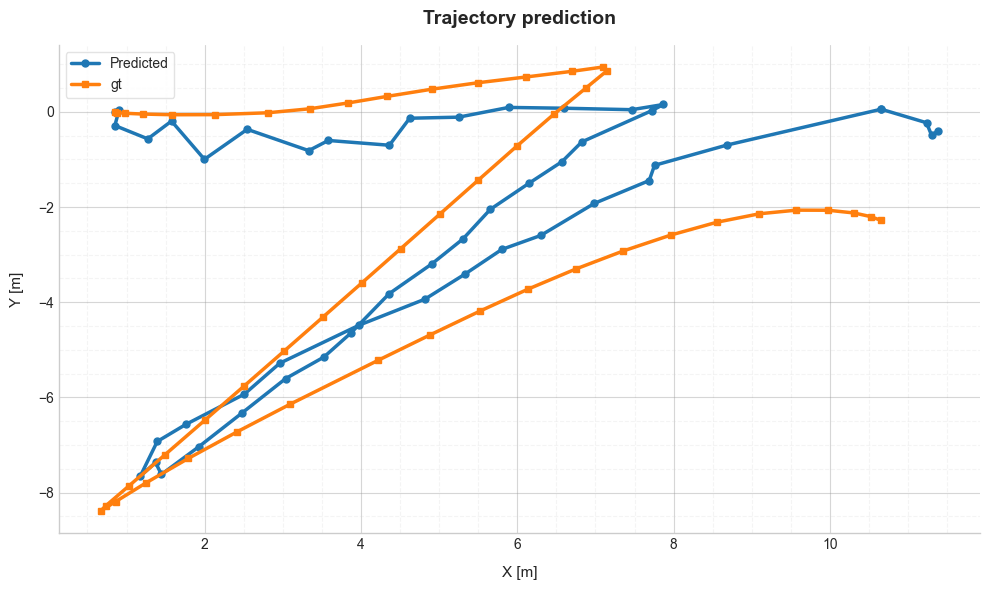

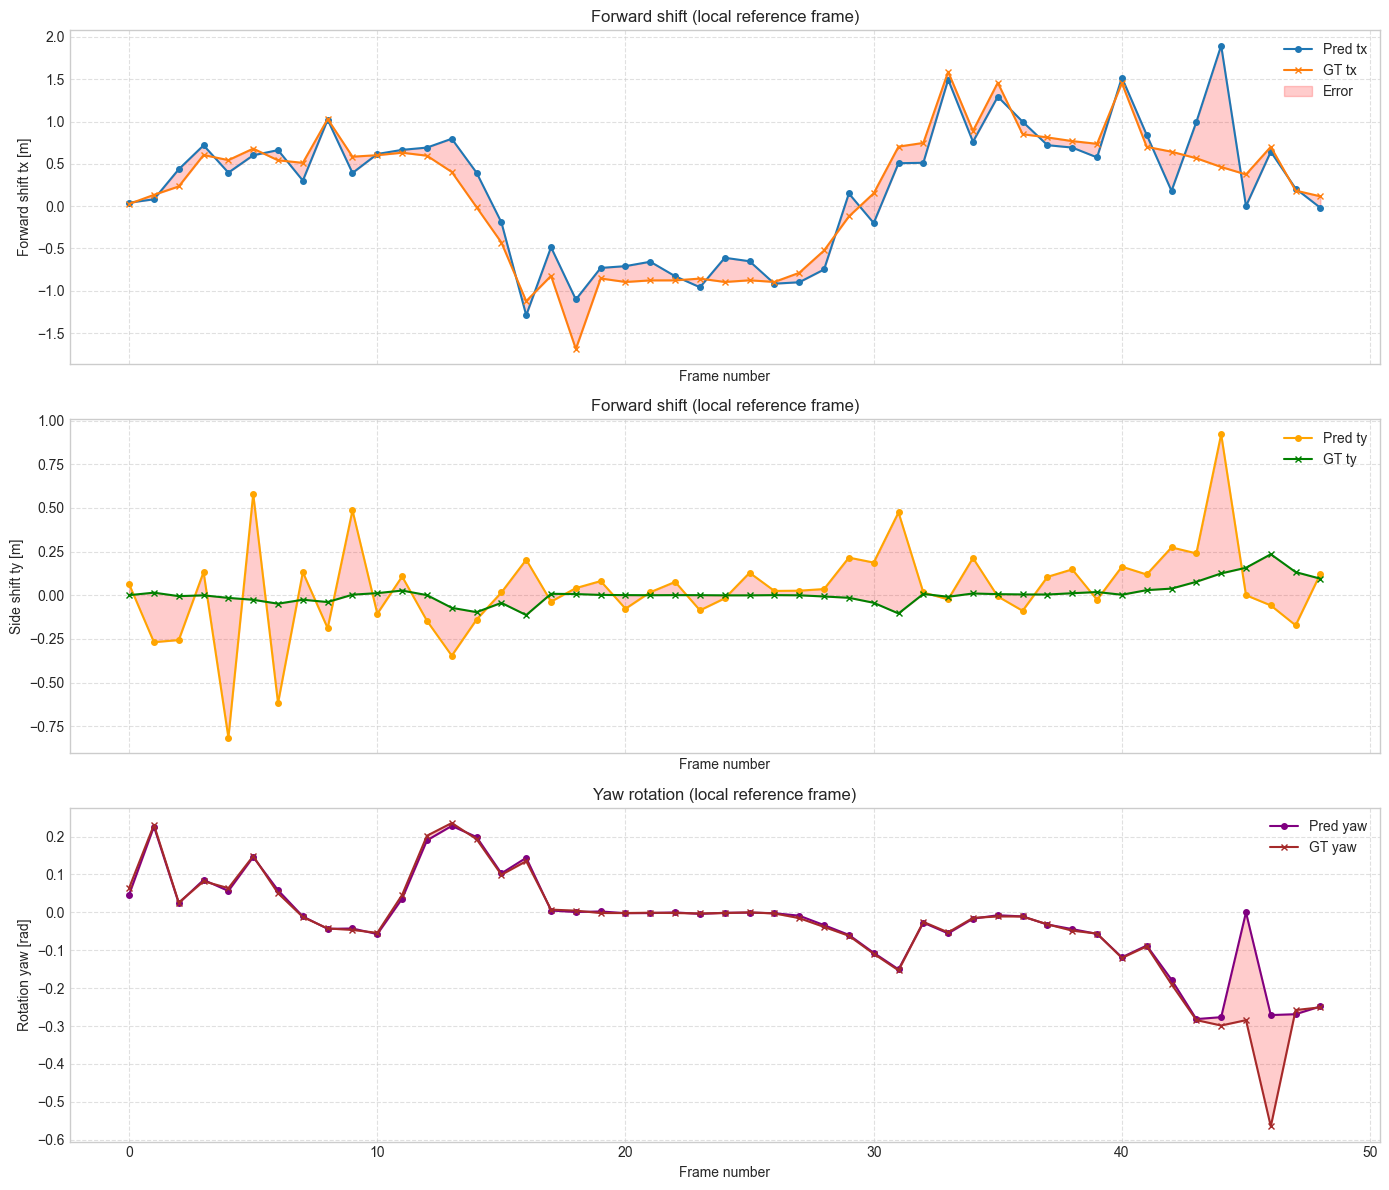

In [97]:
# === visualise results ===

gt_xy_np = np.array(gt_xy)
pred_xy_np = np.array(pred_xy)

n = gt_xy_np.shape[0]

# --- metrics ---
metrics = eval_metrics_2d(pred_xy_np[:,:2], gt_xy_np) # Only compare x,y for ATE/RPE

# print('='*50)
# print('Metrics')
# print(f'Absolute trajectory error: {ATE} [m]')
# print(f'Relative pose error: {RPE} [m]')
# print('='*50)

# --- trajectory ---

start = 0
end = 100

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

ax.plot(pred_xy_np[start:end, 0], pred_xy_np[start:end, 1], label='Predicted', linewidth=2.5, marker='o', markersize=5)
ax.plot(gt_xy_np[start:end, 0], gt_xy_np[start:end, 1], label='gt', linewidth=2.5, marker='s', markersize=5)

ax.minorticks_on()
ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

ax.set_title('Trajectory prediction', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('X [m]', fontsize=11, labelpad=10)
ax.set_ylabel('Y [m]', fontsize=11, labelpad=10)

ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

plt.show()

fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
frames_num = np.arange(len(metrics_local['tx_pred']))

# Wykres TX
axs[0].plot(frames_num, metrics_local['tx_pred'], label='Pred tx', marker='o', markersize=4)
axs[0].plot(frames_num, metrics_local['tx_gt'], label='GT tx', marker='x', markersize=4)
axs[0].fill_between(frames_num, metrics_local['tx_pred'], metrics_local['tx_gt'], color='red', alpha=0.2, label='Error')
axs[0].set_ylabel('Forward shift tx [m]')
axs[0].set_xlabel('Frame number')
axs[0].set_title('Forward shift (local reference frame)')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# Wykres TY
axs[1].plot(frames_num, metrics_local['ty_pred'], label='Pred ty', marker='o', markersize=4, color='orange')
axs[1].plot(frames_num, metrics_local['ty_gt'], label='GT ty', marker='x', markersize=4, color='green')
axs[1].fill_between(frames_num, metrics_local['ty_pred'], metrics_local['ty_gt'], color='red', alpha=0.2)
axs[1].set_ylabel('Side shift ty [m]')
axs[1].set_xlabel('Frame number')
axs[1].set_title('Forward shift (local reference frame)')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

# Wykres YAW
axs[2].plot(frames_num, metrics_local['yaw_pred'], label='Pred yaw', marker='o', markersize=4, color='purple')
axs[2].plot(frames_num, metrics_local['yaw_gt'], label='GT yaw', marker='x', markersize=4, color='brown')
axs[2].fill_between(frames_num, metrics_local['yaw_pred'], metrics_local['yaw_gt'], color='red', alpha=0.2)
axs[2].set_ylabel('Rotation yaw [rad]')
axs[2].set_title('Yaw rotation (local reference frame)')
axs[2].set_xlabel('Frame number')
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
print('--- Data Generator Sample Check ---')
for i in range(start_idx, start_idx + min(max_iter, 5), stride): # Check first 5 samples
    t_check, frame_check, pose_gt_check, depth_check = data_generator.get_sample(i, return_visu=False, return_depth=True)
    print(f"Iteration {i}:")
    print(f"  t type: {type(t_check)}, shape: {t_check.shape if hasattr(t_check, 'shape') else 'N/A'}")
    print(f"  frame type: {type(frame_check)}, shape: {frame_check.shape}")
    print(f"  pose_gt type: {type(pose_gt_check)}, shape: {pose_gt_check.shape}")
    print(f"  depth type: {type(depth_check)}, shape: {depth_check.shape}")
print('--- End Data Generator Sample Check ---')

--- Data Generator Sample Check ---
Iteration 0:
  t type: <class 'torch.Tensor'>, shape: torch.Size([1])
  frame type: <class 'torch.Tensor'>, shape: torch.Size([1, 1, 1, 200, 192])
  pose_gt type: <class 'torch.Tensor'>, shape: torch.Size([7])
  depth type: <class 'torch.Tensor'>, shape: torch.Size([1])
Iteration 1:
  t type: <class 'torch.Tensor'>, shape: torch.Size([1])
  frame type: <class 'torch.Tensor'>, shape: torch.Size([1, 1, 1, 200, 192])
  pose_gt type: <class 'torch.Tensor'>, shape: torch.Size([7])
  depth type: <class 'torch.Tensor'>, shape: torch.Size([1])
Iteration 2:
  t type: <class 'torch.Tensor'>, shape: torch.Size([1])
  frame type: <class 'torch.Tensor'>, shape: torch.Size([1, 1, 1, 200, 192])
  pose_gt type: <class 'torch.Tensor'>, shape: torch.Size([7])
  depth type: <class 'torch.Tensor'>, shape: torch.Size([1])
Iteration 3:
  t type: <class 'torch.Tensor'>, shape: torch.Size([1])
  frame type: <class 'torch.Tensor'>, shape: torch.Size([1, 1, 1, 200, 192])
  po

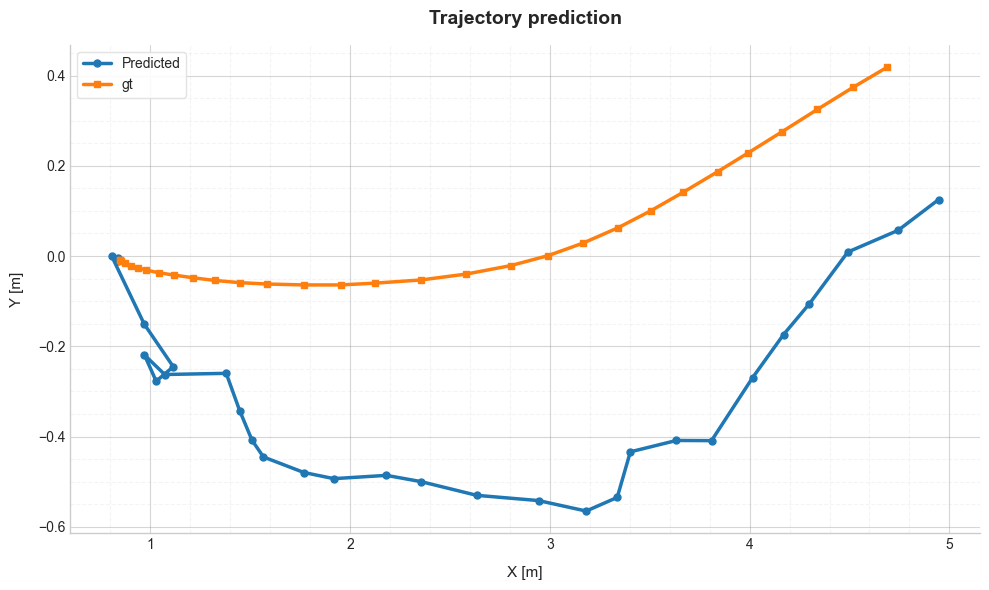

In [ ]:

# --- trajectory ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

ax.plot(pred_xy_np[:, 0], pred_xy_np[:, 1], label='Predicted', linewidth=2.5, marker='o', markersize=5)
ax.plot(gt_xy_np[:, 0], gt_xy_np[:, 1], label='gt', linewidth=2.5, marker='s', markersize=5)

ax.minorticks_on()
ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

ax.set_title('Trajectory prediction', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('X [m]', fontsize=11, labelpad=10)
ax.set_ylabel('Y [m]', fontsize=11, labelpad=10)

ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

plt.show()

In [ ]:
# save prediction to file
import csv

n = pred_xy_np.shape[0]
filename = os.path.join(data_root_dir, 'pred.csv')

with open(filename, mode='w', newline='') as file:
  writer = csv.writer(file)

  writer.writerow(['timestamp', 'x', 'y', 'z', 'q_x', 'q_y', 'q_z', 'q_w'])

  for i in range(n):

      timestamp = i + 1

      x = pred_xy_np[i, 0]
      y = pred_xy_np[i, 1]
      z = 0.0
      theta = pred_xy_np[i, 2]

      q_x = 0.0
      q_y = 0.0
      q_z = np.sin(theta / 2.0)
      q_w = np.cos(theta / 2.0)

      writer.writerow([timestamp, x, y, z, q_x, q_y, q_z, q_w])

  print(f"Saved {n} frames to file: {filename}")

Saved 30 frames to file: C:/Users/janis/Projekty/Magisterka/SonarOdometry\SonarOdometryDataset/selfsupervised/val/seq_15\pred.csv
